In [18]:
from typing import TypedDict, Annotated, Sequence
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, SystemMessage
from langchain_openai import ChatOpenAI 
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv

In [ ]:
#the code needs corection, it doesn't work as expected

load_dotenv()
model=ChatOpenAI(model="gpt-4-turbo")

In [20]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [21]:
@tool
def add(a:int, b:int)-> int:
    """This will ad 2 numbers"""
    return a+b

@tool
def sub(a:int, b:int)-> int:
    """This will ad 2 numbers"""
    return a-b

@tool
def mul(a:int, b:int)-> int:
    """This will ad 2 numbers"""
    return a*b

@tool
def div(a:int, b:int)-> int:
    """This will ad 2 numbers"""
    return a/b

In [22]:
my_tools=[add, sub, mul, div]
model=model.bind_tools(my_tools)

def model_call(state:AgentState)->AgentState:
    system_prompt=SystemMessage(content="You are an AI assisstant, please answer my query to the best of your ability")
    inputs=[system_prompt]+state['messages']
    response=model.invoke(inputs)
    return {"messages":state['messages']+[response]}

def should_continue(state:AgentState):
    message=state['messages']
    last_message=message[-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"
    
    

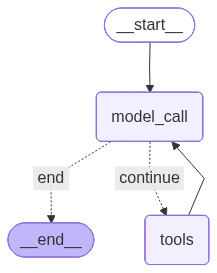

In [23]:
graph=StateGraph(AgentState)
graph.add_node("model_call", model_call)

tool_node=ToolNode(tools=my_tools)
graph.add_node("tools", tool_node)

graph.add_edge(START, "model_call")
graph.add_conditional_edges(
    "model_call",
    should_continue,
    {
        "end":END,
        "continue":"tools"
    }
)

graph.add_edge("tools", "model_call")
graph.add_edge("model_call", END)

bot=graph.compile()
bot

In [25]:
def print_stream(stream):
    for s in stream:
        node_name, node_value=next(iter(s.items())) 
        if 'messages' in node_value:
            message=node_value['messages'][-1]
            if(isinstance(message, tuple)):
                print(message)
            else:
                message.pretty_print()

inputs={"messages" :[("user", "add 4 and 2 and then calculate the product with 6. also tell me a joke at the end")]}
print_stream(bot.stream(inputs))

================================== Ai Message ==================================
Tool Calls:
  add (call_HQOFhkXdFa5jwbI3F3X6T9pp)
 Call ID: call_HQOFhkXdFa5jwbI3F3X6T9pp
  Args:
    a: 4
    b: 2
  mul (call_JffpNmnneEk5hiEvxrzD2Hn0)
 Call ID: call_JffpNmnneEk5hiEvxrzD2Hn0
  Args:
    a: 4
    b: 6
================================= Tool Message =================================
Name: mul

24
================================== Ai Message ==================================

The sum of 4 and 2 is 6, and the product of 4 and 6 is 24.

Now, here's a joke for you:
Why don't scientists trust atoms?
Because they make up everything!
